# Калькулятор нагрузки и VM / Load & VM calculator

**RU:** Измените `configs/project.yaml` и запустите **Run All**. Результат: пиковая нагрузка, необходимая мощность, подходящая VM у каждого провайдера и месячная стоимость.

**EN:** Edit `configs/project.yaml` and run **Run All**. The result shows peak load, required capacity, one suitable VM layout per provider, and monthly cost.

In [11]:
from pathlib import Path
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import capacity_planner.models as models_module
import capacity_planner.io as io_module
import capacity_planner.simple as planner

# A running Jupyter kernel caches imported Python modules. Reload project code so
# Run All always uses the current calculator schema after a git pull or edit.
importlib.reload(models_module)
planner = importlib.reload(planner)
io_module = importlib.reload(io_module)

catalog_file = ROOT / "configs" / "providers.full.json"
project_config_file = ROOT / "configs" / "project.yaml"
catalog = io_module.load_catalog(catalog_file)
metrics = io_module.load_project_metrics(project_config_file)
print(f"Loaded {len(catalog):,} VM records from {catalog_file.name}")
print(f"Loaded project parameters from {project_config_file.name}")
print(f"Python kernel: {sys.executable}")
if ".venv1" in sys.executable:
    display(Markdown(
        "Restart required / Нужен перезапуск:** select `Kernel → Change Kernel → "
        "Project .venv (Python 3.12)`, then run all cells."
    ))

Loaded 1,222 VM records from providers.full.json
Loaded project parameters from project.yaml
Python kernel: /Users/herman/Documents/ChatGPT/Econometrics/Elastic-Compute-Load-Profiling-Capacity-Planning/.venv/bin/python


## 1. Входные данные / Inputs

**RU:** Параметры загружаются из `configs/project.yaml`. Изменяйте YAML, а не код notebook. `rpc_per_event` — сколько внутренних вызовов сервисов создаёт одно действие пользователя.

**EN:** Parameters are loaded from `configs/project.yaml`. Edit YAML, not notebook code. `rpc_per_event` is the number of internal service calls caused by one user action.

In [12]:
input_values = pd.DataFrame(
    [{"Parameter / Параметр": key, "Value / Значение": value}
     for key, value in metrics.__dict__.items()]
)
display(input_values.style.hide(axis="index"))

Parameter / Параметр,Value / Значение
mau,1000.000000
dau_percent,5.000000
business_events_per_user_day,20.000000
rpc_per_event,3.000000
active_hours_day,8.000000
peak_factor,4.000000
cpu_ms_per_rpc,5.000000
latency_ms,100.000000
memory_mib_per_inflight,1.000000
base_ram_gib,1.000000


## 2. Результат для бизнеса / Business result

**RU:** Здесь только показатели, необходимые для решения о мощности и бюджете.

**EN:** Only the metrics needed for a capacity and budget decision are shown here.

In [14]:
result = planner.build_business_summary(metrics, catalog)
load = result["load"]

kpis = pd.DataFrame([
    ["DAU", f'{load["dau"]:,.0f}', "Daily active users / Активных в день"],
    ["Peak RPS", f'{load["peak_event_rps"]:,.1f}', "Peak user actions/s / Пиковых действий/с"],
    ["Peak RPC", f'{load["peak_rpc"]:,.1f}', "Peak internal calls/s / Внутренних вызовов/с"],
    ["Required vCPU", f'{load["required_vcpu"]:,.2f}', "At target utilization / При целевой загрузке"],
    ["Required RAM", f'{load["required_ram_gib"]:,.2f} GiB', "Working set estimate / Оценка рабочей памяти"],
    ["Monthly RPC", f'{load["monthly_rpc"]:,.0f}', "Including growth / С учётом роста"],
    ["SLA downtime budget", f'{load["downtime_budget_minutes_month"]:,.2f} min/month', "Target, not provider guarantee / Цель, не гарантия"],
], columns=["Metric / Метрика", "Value / Значение", "Meaning / Смысл"])
display(kpis.style.hide(axis="index"))

Metric / Метрика,Value / Значение,Meaning / Смысл
DAU,50,Daily active users / Активных в день
Peak RPS,0.2,Peak user actions/s / Пиковых действий/с
Peak RPC,0.5,Peak internal calls/s / Внутренних вызовов/с
Required vCPU,0.00,At target utilization / При целевой загрузке
Required RAM,1.00 GiB,Working set estimate / Оценка рабочей памяти
Monthly RPC,"117,000",Including growth / С учётом роста
SLA downtime budget,43.20 min/month,"Target, not provider guarantee / Цель, не гарантия"


## 3. Что купить / What to buy

**RU:** Самый дешёвый подходящий вариант для каждого провайдера. Показаны две цены: без резерва и с топологией под заданный SLA. Для российских облаков исходная цена в рублях является основной; USD нужен только для сравнения. Сеть, диски, IP, лицензии и скидки считаются отдельно.

**EN:** Lowest-cost feasible option for each provider. Both prices are shown: without reserve and HA with a reserve VM. Network, disks, licences, and discounts are separate.

Provider / Провайдер,Region / Регион,VM,Working VM,Reserve VM,Physical vCPU,Effective vCPU,RAM GiB total,Peak CPU %,Peak RAM %,Why / Причина,USD/month without reserve,USD/month SLA,Catalog scope,VM checked,Native/month without reserve,Native/month SLA
Cloud.ru,Russia / Evolution,VM 10% 1vCPU/2GB RAM,1,1,2.000000,0.200000,4.000000,2.71%,50.00%,minimum availability,$4.23,$8.45,complete_published_cpu_tariff,49,356.48 RUB,712.97 RUB
Google Cloud,us-central1 (Iowa),e2-small,1,1,4.000000,1.000000,4.000000,0.54%,50.00%,minimum availability,$12.06,$24.12,partial,3,12.06 USD,24.12 USD
Yandex Cloud,ru-central1,standard-v3 / 2 vCPU 20% / 2 GiB,1,1,4.000000,0.800000,4.000000,0.68%,50.00%,minimum availability,$14.51,$29.03,documented_examples,3,"1,224.00 RUB","2,448.00 RUB"
AWS,eu-central-1,t3a.small,1,1,4.000000,0.800000,4.000000,0.68%,50.00%,minimum availability,$15.55,$31.10,complete_region_price_feed,740,15.55 USD,31.10 USD
Microsoft Azure,westeurope,Standard_B1ms,1,1,2.000000,0.400000,4.000000,1.35%,50.00%,minimum availability,$17.28,$34.56,partial,2,17.28 USD,34.56 USD
Nebius AI Cloud,eu-north1,cpu-d3 / 2vCPU-8GB,1,1,4.000000,4.000000,16.000000,0.14%,12.50%,minimum availability,$35.71,$71.42,complete_non_gpu_presets,17,35.71 USD,71.42 USD


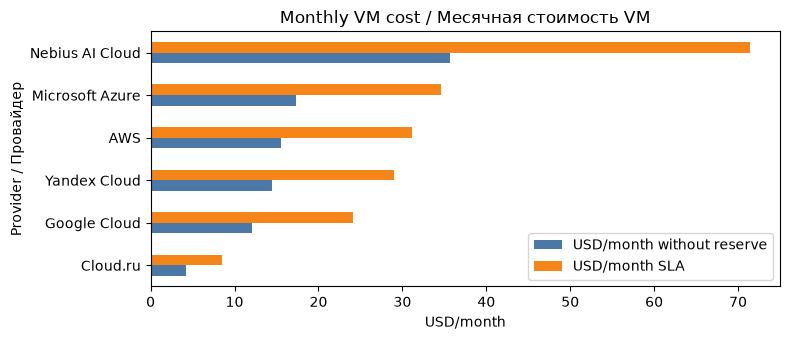

⚠️ **Catalog limitation / Ограничение каталога:** catalog is not exhaustive for Google Cloud, Yandex Cloud, Microsoft Azure. Their result is based on verified examples, not a provider-wide exhaustive optimum.

In [15]:
# Recalculate here too, so running this cell never reuses a stale result.
result = planner.build_business_summary(metrics, catalog)
offers = pd.DataFrame(result["recommendations"])
required_columns = {
    "peak_cpu_utilization_percent", "peak_ram_utilization_percent",
    "limiting_factor", "catalog_choices",
}
missing_columns = required_columns.difference(offers.columns)
if missing_columns:
    raise RuntimeError(
        "Stale calculator module. Restart the kernel, select Project .venv "
        f"(Python 3.12), and Run All. Missing: {sorted(missing_columns)}"
    )
visible = offers[[
    "provider", "region", "vm", "working_instances", "reserve_instances",
    "total_vcpu", "total_effective_vcpu", "total_ram_gib",
    "peak_cpu_utilization_percent", "peak_ram_utilization_percent",
    "limiting_factor", "monthly_native_without_reserve", "monthly_native_ha",
    "price_currency", "monthly_usd_without_reserve", "monthly_usd",
    "catalog_scope", "catalog_choices"
]].copy()
visible["Native/month without reserve"] = visible.apply(
    lambda x: f'{x["monthly_native_without_reserve"]:,.2f} {x["price_currency"]}', axis=1
)
visible["Native/month SLA"] = visible.apply(
    lambda x: f'{x["monthly_native_ha"]:,.2f} {x["price_currency"]}', axis=1
)
visible = visible.drop(columns=[
    "monthly_native_without_reserve", "monthly_native_ha", "price_currency"
])
visible.columns = [
    "Provider / Провайдер", "Region / Регион", "VM", "Working VM", "Reserve VM",
    "Physical vCPU", "Effective vCPU", "RAM GiB total", "Peak CPU %", "Peak RAM %",
    "Why / Причина", "USD/month without reserve", "USD/month SLA",
    "Catalog scope", "VM checked", "Native/month without reserve", "Native/month SLA"
]
display(visible.style.format({
    "Peak CPU %": "{:,.2f}%", "Peak RAM %": "{:,.2f}%",
    "USD/month without reserve": "${:,.2f}", "USD/month SLA": "${:,.2f}"
}).hide(axis="index"))

if not visible.empty:
    ax = visible.sort_values("USD/month SLA").plot.barh(
        x="Provider / Провайдер",
        y=["USD/month without reserve", "USD/month SLA"],
        figsize=(8, 3.5), color=["#4C78A8", "#F58518"]
    )
    ax.set_title("Monthly VM cost / Месячная стоимость VM")
    ax.set_xlabel("USD/month")
    plt.tight_layout()
    plt.show()

limited = visible.loc[
    visible["Catalog scope"].isin(["partial", "documented_examples"]),
    "Provider / Провайдер"
].tolist()
if limited:
    display(Markdown(
        "Catalog limitation / Ограничение каталога:** catalog is not exhaustive for "
        + ", ".join(limited)
        + ". Their result is based on verified examples, not a provider-wide exhaustive optimum."
    ))

## 4. Решение и ограничения / Decision and limits

**RU:** `availability_sla_percent` задаёт целевую топологию калькулятора: ниже 99.9% — 1 VM; 99.9% — 2 VM; 99.95% — 3 VM; 99.99% — 4 VM. Это инженерный запас, а не юридическая гарантия SLA. Выберите провайдера не только по минимальной цене: проверьте зоны доступности, договорной SLA и стоимость трафика/дисков. Значения `cpu_ms_per_rpc` и памяти должны быть заменены результатами короткого нагрузочного теста.

**EN:** `availability_sla_percent` maps to a planning topology: below 99.9% — 1 VM; 99.9% — 2 VMs; 99.95% — 3 VMs; 99.99% — 4 VMs. This is engineering redundancy, not a contractual SLA guarantee. Validate availability zones, contractual SLA, traffic, and disk cost. Replace CPU and memory assumptions with a short load test.

**RU:** Цена меняется ступенчато, а не вместе с каждым изменением MAU. Пока нагрузка помещается в ту же минимальную VM и действует `min_instances`, тип VM и месячная цена останутся прежними. `Why / Причина` показывает, ограничен ли выбор CPU, RAM или политикой доступности.

**EN:** VM pricing is stepwise. While the workload still fits the same smallest VM and `min_instances` applies, the VM and monthly price correctly remain unchanged. `Why / Причина` identifies whether CPU, RAM, or the availability floor drives the purchase.

<details><summary>Техническая проверка / Technical audit</summary>

The compact model uses: DAU = MAU × DAU%; peak RPS = daily events / active seconds × peak factor; peak RPC = peak RPS × RPC/event; required vCPU = peak RPC × CPU seconds / target utilization. These are audit equations, not additional business inputs.

</details>

## 5. Охват каталога / Catalog coverage

**RU:** Эта таблица нужна только для контроля полноты каталога, а не для принятия решения.

**EN:** This table is only a catalog-completeness check, not part of the decision flow.

In [16]:
coverage = (
    pd.DataFrame([{"provider": x.provider, "category": x.category, "vm": x.sku} for x in catalog])
    .groupby(["provider", "category"])["vm"].nunique().rename("VM count").reset_index()
)
display(coverage)

,provider,category,VM count
0,AWS,burstable,28
1,AWS,compute_optimized,279
2,AWS,fpga,5
3,AWS,general_purpose,282
4,AWS,gpu,67
5,AWS,memory_optimized,383
6,AWS,ml_accelerator,9
7,AWS,storage_optimized,90
8,Cloud.ru,general_purpose,30
9,Cloud.ru,shared_core,22
